In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [15]:
exoplanet_data = pd.read_csv("exoplanet_data.csv", comment="#")
np.shape(exoplanet_data) # (570, 92) 570 rows, 92 columns
print(list(exoplanet_data.columns))
# sy_gaimagerr1, plt.eqtlim, pl_bmasselim, pl_bmas, pl_orbper

['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2', 'st_masslim', 'st_met', 'st_meterr1', 'st_meterr2', 'st_metlim', 'st_metratio', 'st_logg', 'st

In [ ]:
# Table Label: Planet Name
# Database Column Name: pl_name
# Description: Most common planet name
# Describe: the most well-known name that is easily recognized

# Table Label: Host Name
# Database Column Name: hostname
# Description: most common stellar name
# Describe: most well-known stellar name

# Table Label: Discovery Method
# Database Column Name: discoverymethod
# Description: the method used to identify the planet for the first time
# Describe: what tools or instruments were used to recognize and determine a new planet

# Table Label: Spectral Type
# Database Column Name: st_spectype
# Description: classification system for stars based on their spectral characteristics
# Describe: a way to classify stars based off of their specifc characteristics

# Table Label: Equilibrium Temperature
# Database Column Name: pl_eqt
# Description: The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body
# Describe: temperature (i have no idea)

# Table Label: Planet Mass or Mass*sin(i) [Earth Mass]
# Database Column Name: pl_bmasse
# Description: Best planet mass estimate available, in order of preference: Mass, M*sin(i)/sin(i), or M*sin(i), depending on availability, and measured in Earth masses
# Describe: best planet mass estimate (idk what preference means here)

In [17]:
reduced_datfr=exoplanet_data[['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt', 'pl_bmasse']]

In [18]:
reduced_datfr

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmasse
0,7 CMa c,7 CMa,Radial Velocity,NaN,NaN,289.900000
1,7 CMa c,7 CMa,Radial Velocity,NaN,NaN,276.512100
2,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,24.270000
3,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,9.600000
4,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,3.350000
...,...,...,...,...,...,...
565,bet Pic c,bet Pic,Radial Velocity,NaN,1250.0,2606.192937
566,bet Pic c,bet Pic,Radial Velocity,NaN,NaN,3222.462219
567,bet Pic c,bet Pic,Radial Velocity,NaN,NaN,2860.470000
568,eps Ind A b,eps Ind A,Radial Velocity,K5 V,275.0,2005.497248


In [19]:
rereduced_datfr=reduced_datfr.dropna(axis=1)

In [20]:
rereduced_datfr

,pl_name,hostname,discoverymethod
0,7 CMa c,7 CMa,Radial Velocity
1,7 CMa c,7 CMa,Radial Velocity
2,DMPP-1 b,DMPP-1,Radial Velocity
3,DMPP-1 c,DMPP-1,Radial Velocity
4,DMPP-1 d,DMPP-1,Radial Velocity
...,...,...,...
565,bet Pic c,bet Pic,Radial Velocity
566,bet Pic c,bet Pic,Radial Velocity
567,bet Pic c,bet Pic,Radial Velocity
568,eps Ind A b,eps Ind A,Radial Velocity


In [22]:
np.shape(rereduced_datfr) # now 3 columns, 570 rows

(570, 3)

In [24]:
print(rereduced_datfr.tail())
print(rereduced_datfr.head())
print(list(rereduced_datfr.columns))

         pl_name   hostname  discoverymethod
565    bet Pic c    bet Pic  Radial Velocity
566    bet Pic c    bet Pic  Radial Velocity
567    bet Pic c    bet Pic  Radial Velocity
568  eps Ind A b  eps Ind A  Radial Velocity
569  eps Ind A b  eps Ind A  Radial Velocity
    pl_name hostname  discoverymethod
0   7 CMa c    7 CMa  Radial Velocity
1   7 CMa c    7 CMa  Radial Velocity
2  DMPP-1 b   DMPP-1  Radial Velocity
3  DMPP-1 c   DMPP-1  Radial Velocity
4  DMPP-1 d   DMPP-1  Radial Velocity
['pl_name', 'hostname', 'discoverymethod']


In [28]:
print(rereduced_datfr.value_counts('discoverymethod'))
# transit, 389. Occurs when a planet passes between a star and its observer and the change in light of the star is visible to us.
# radial velocity, 109. Orbiting planets cause stars to appear to wobble, which changes the color of the light that we can observe
# microlensing, 61. An observational effect where the presence of mass in space warps space-time. This warping can be detectable and could be the work of a planet
# imaging, 5. By blocking the star's light that hides the dimmer exoplanet, the exoplanets became easier to see and image
# transit timing variations, 3. When two planets are in orbit, one planet's pull can accelerate the other while it decelerates, affecting each planet's orbital period to change.
# eclipse timing variations, 2. When a binary star system's eclipse timing is altered due to the influence of an orbiting planet's gravity
# disk kinematics, 1. When deviations in a star's protoplanetary disk gas velocity occur.
# transit has the most. disk kinematics has the least


discoverymethod
Transit                      389
Radial Velocity              109
Microlensing                  61
Imaging                        5
Transit Timing Variations      3
Eclipse Timing Variations      2
Disk Kinematics                1
Name: count, dtype: int64


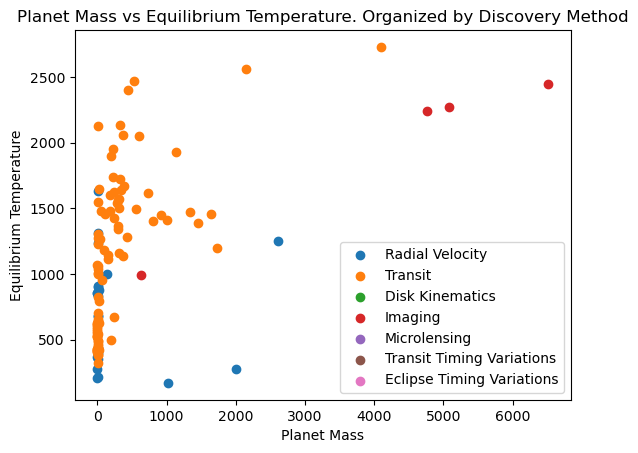

In [35]:
methods=reduced_datfr['discoverymethod'].unique()
for method in methods:
    subset=reduced_datfr[reduced_datfr['discoverymethod']==method]
    plt.scatter(subset['pl_bmasse'],subset['pl_eqt'], label=method)

plt.xlabel("Planet Mass")
plt.ylabel("Equilibrium Temperature")
plt.title("Planet Mass vs Equilibrium Temperature. Organized by Discovery Method")
plt.legend()
plt.show()

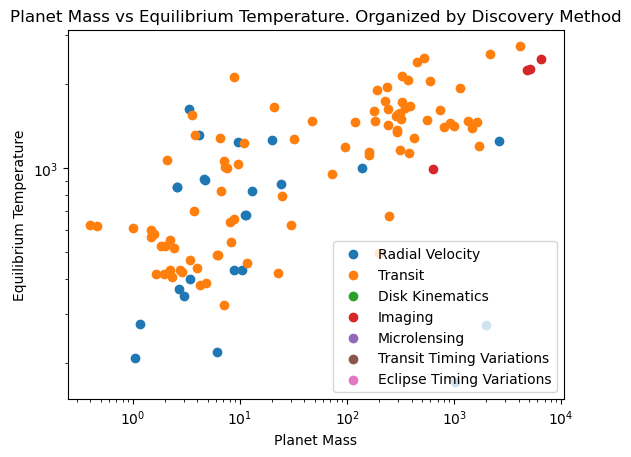

In [38]:
methods=reduced_datfr['discoverymethod'].unique()
for method in methods:
    subset=reduced_datfr[reduced_datfr['discoverymethod']==method]
    plt.scatter(subset['pl_bmasse'],subset['pl_eqt'], label=method)

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Planet Mass")
plt.ylabel("Equilibrium Temperature")
plt.title("Planet Mass vs Equilibrium Temperature. Organized by Discovery Method")
plt.legend()
plt.show()

In [39]:
# exoplanets found by imaging are more likely to be massive

In [40]:
massive_planets=reduced_datfr[reduced_datfr['pl_bmasse']>5]
coldest_planet=massive_planets.loc[massive_planets['pl_eqt'].idxmin()]
print(f"Name: {coldest_planet['pl_name']}")
print(f"Mass: {coldest_planet['pl_bmasse']} Jupiter Masses")
print(f"Equilibrium Temperature: {coldest_planet['pl_eqt']} K")

Name: HR 5183 b
Mass: 1026.5909 Jupiter Masses
Equilibrium Temperature: 171.0 K


In [41]:
print(coldest_planet)

pl_name                  HR 5183 b
hostname                   HR 5183
discoverymethod    Radial Velocity
st_spectype                    NaN
pl_eqt                       171.0
pl_bmasse                1026.5909
Name: 217, dtype: object


In [43]:
# name: HR 5183 b
# index: 217
# 171.0 K
# 1026.6 JM
# not recorded
# unknown

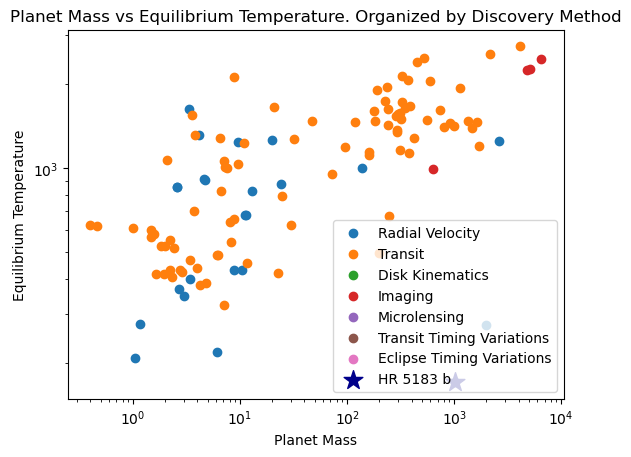

In [45]:
methods=reduced_datfr['discoverymethod'].unique()
for method in methods:
    subset=reduced_datfr[reduced_datfr['discoverymethod']==method]
    plt.scatter(subset['pl_bmasse'],subset['pl_eqt'], label=method)
coldest_planet=reduced_datfr.loc[217]
plt.scatter(coldest_planet['pl_bmasse'], coldest_planet['pl_eqt'],
            color='darkblue',
            marker='*',
            s=200,
            label=coldest_planet['pl_name'])

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Planet Mass")
plt.ylabel("Equilibrium Temperature")
plt.title("Planet Mass vs Equilibrium Temperature. Organized by Discovery Method")
plt.legend()
plt.show()

In [ ]:
# title: A temperate super-Jupiter imaged with JWST in the mid-infrared
# summary: JWST discovered a new super large planet orbiting a young star. This plane was identified using radial-velicty and astronmetric accelration methods. Imaging showed that the planet had characteristics inconsistent with previous observations including a new temperature, brightness, and opacity of the atmoshphere. It could be the only giant planet in the system
# my planet was not correct. The correct one was Eps Ind Ab
# HR 5183 b is a gas giant exoplanet that orbits a G-type star. Its mass is 3.31 Jupiters, it takes 74 years to complete one orbit of its star, and is 18.0 AU from its star.
# mine was incorrect so there is no comparison to report